In [1]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import importlib
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


import books
import data_io as f1
import series_utils as f2
import config

plt.style.use('dark_background')

Text(0.5, 1.0, 'prices for USDCHF.FOREX from 2025-1-02 to 2025-10-27')

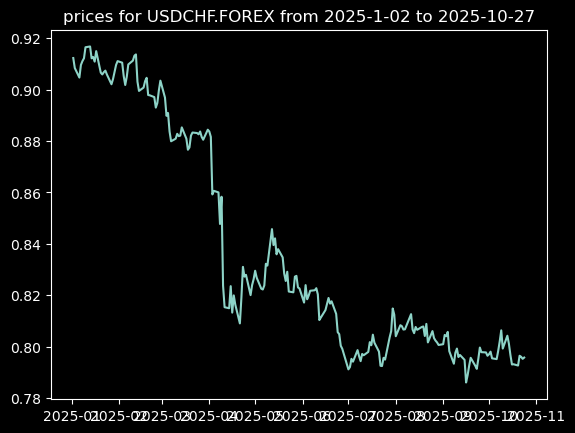

In [17]:
# WE NEED OHCL TO CREATE THE CHANNEL !!!
ticker='USDCHF.FOREX'
start='2025-1-02'
end='2025-10-27'
s =f1.fetch_csv(ticker, params=config.params)
s=f1.sort_cols(s, ohlc=True)
s=f2.trim_series(s, start, end)

plt.plot(s.index, s['Close'].values)
px = s['Close'].values
# # give plot a title
plt.title(f'prices for {ticker} from {start} to {end}')
# plt.show8

# slope=(s.iloc[-1]-s.iloc[0])/lens
# print('slope',slope)



In [18]:



index = np.arange(len(px), dtype=float)
# lr = linregress(index, logp.values)  # slope, intercept, r, p, stderr
lr = linregress(index, px.values)  # slope, intercept, r, p, stderr
tstat_price = lr.slope / lr.stderr if lr.stderr else np.nan
mu_day = lr.slope # approx daily drift in price terms (per day)
mu_ann = mu_day * 252

print(f"price t-stat: {tstat_price:.2f}, R2={lr.rvalue**2:.3f}, mu_day={mu_day:.6f}, mu_ann≈{mu_ann:.3f}")

# Fitted trend in price space for plotting. y'hat' means predicted
# yhat_log = lr.intercept + lr.slope * index
yhat = lr.intercept + lr.slope * index
# yhat = np.exp(yhat_log)
yhat = pd.Series(yhat, index=px.index)
# get t-stat
s_t = lr.slope / lr.stderr if lr.stderr else np.nan
print(f"t-stat={s_t:.2f}")


AttributeError: 'numpy.ndarray' object has no attribute 'values'

#### FIT AN OLS LINE TO THE PRICE SERIES

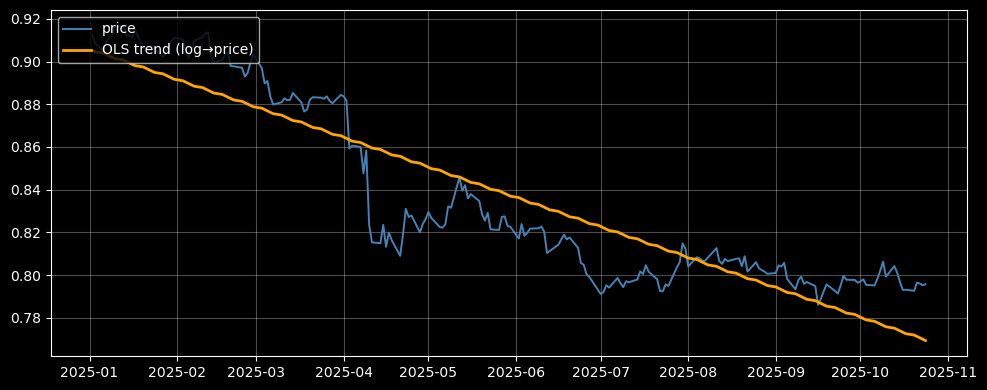

In [ ]:

# Plot actual price vs fitted trend
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(s.index, s.values, label='price', color='steelblue', lw=1.4)
ax.plot(yhat.index, yhat.values, label='OLS trend (log→price)', color='orange', lw=2.0)
ax.legend(loc='upper left'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:
# work out max / mins of daily bars in price series
print('max / min of daily bars in price series:', s.max(), s.min())

# plot these channel boundaries


max / min of daily bars in price series: 0.9168 0.786
